╒════╤═════════════════╤═══════════╤═══════════╤═════════════╤════════════╤═════════╤═════════════════╕
│    │ Type            │ Comment   │    Radius │   Thickness │ Material   │   Conic │   Semi-aperture │
╞════╪═════════════════╪═══════════╪═══════════╪═════════════╪════════════╪═════════╪═════════════════╡
│  0 │ Planar          │           │  inf      │    inf      │ Air        │       0 │         8.66078 │
│  1 │ Standard        │           │   16.1102 │      5      │ K5         │       0 │         8.66078 │
│  2 │ Standard        │           │ -111.876  │      4.222  │ Air        │       0 │         6.91951 │
│  3 │ Stop - Standard │           │  -24.2175 │      2      │ F2         │       0 │         4.54455 │
│  4 │ Standard        │           │   14.4709 │      5.7652 │ Air        │       0 │         4.82682 │
│  5 │ Standard        │           │   37.3425 │      3.7    │ N-BK7      │       0 │         7.33726 │
│  6 │ Standard        │           │  -18.7713 │     39.79   │ A

(<Figure size 2000x800 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

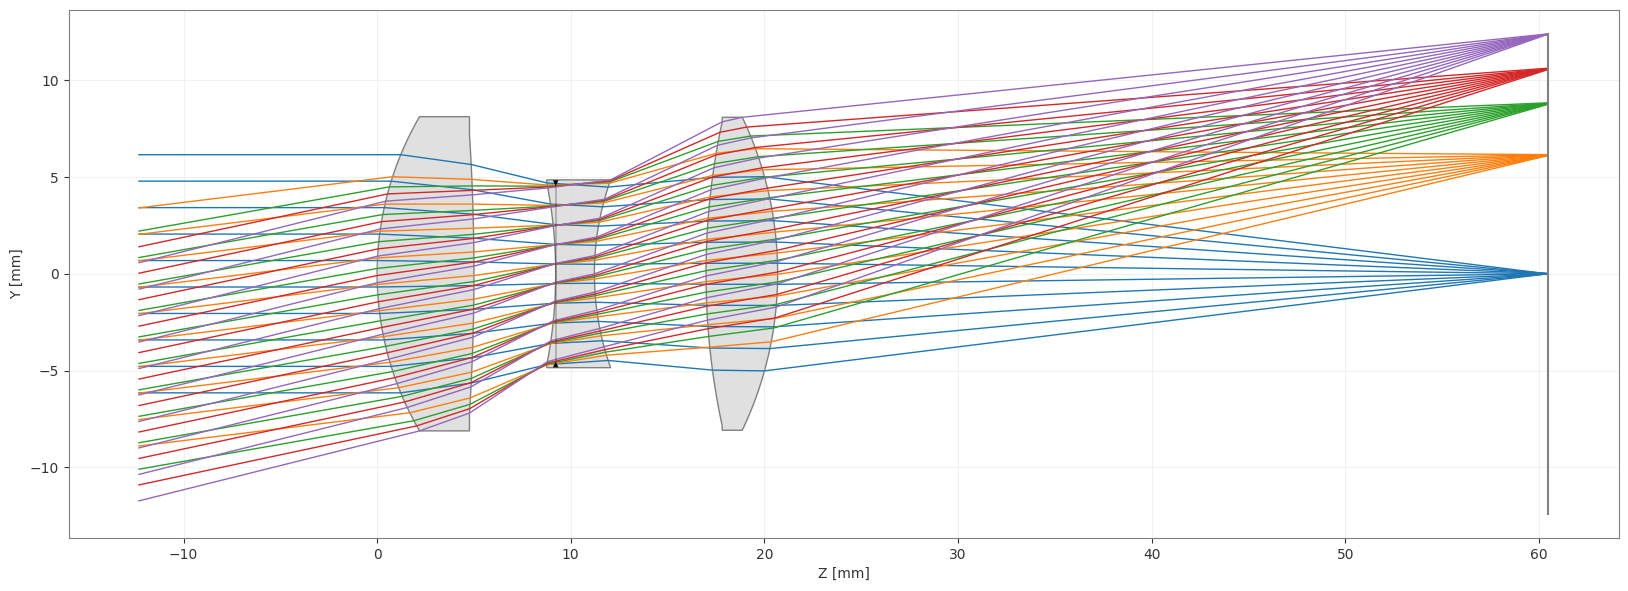

In [111]:
import numpy as np

from optiland import optic, analysis, optimization

lens = optic.Optic()

# define surfaces
lens.surfaces.add(index=0, radius=np.inf, thickness=np.inf)
lens.surfaces.add(index=1, material="K5", radius=16.1102, thickness=5)
lens.surfaces.add(index=2, radius=-111.876,  thickness=4.222)
lens.surfaces.add(index=3, is_stop=True, material="F2", radius=-24.2175,  thickness=2)
lens.surfaces.add(index=4, radius=14.4709, thickness=5.7652)
lens.surfaces.add(index=5, material="N-BK7", radius=37.3425, thickness=3.7)
lens.surfaces.add(index=6, radius=-18.7713,  thickness=39.79)
lens.surfaces.add(index=7)

# define aperture
lens.set_aperture(aperture_type="EPD", value=12.3)

# define fields
lens.fields.set_type(field_type="angle")
lens.fields.add(y=0)
lens.fields.add(y=7)
lens.fields.add(y=10)
lens.fields.add(y=12)
lens.fields.add(y=14)

# define wavelengths
lens.wavelengths.add(value=0.486)
lens.wavelengths.add(value=0.588, is_primary=True)
lens.wavelengths.add(value=0.656)

# lens data
lens.info()

# view in 2D
lens.draw(num_rays=10, figsize=(20, 8))

In [112]:
print(f"Focal length: {lens.paraxial.f2():.3f} mm")
print(f"Image-space F-Number: {lens.paraxial.FNO():.3f}")

Focal length: 50.310 mm
Image-space F-Number: 4.090


(<Figure size 700x450 with 1 Axes>,
 <Axes: xlabel='Normalized Y Field Coordinate', ylabel='RMS Spot Size (mm)'>)

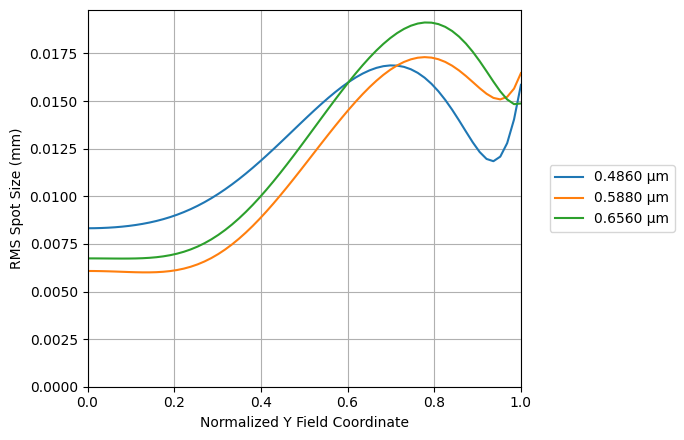

In [113]:
rms_vs_field = analysis.RmsSpotSizeVsField(lens)
rms_vs_field.view()

(<Figure size 1200x800 with 5 Axes>,
 [<Axes: title={'center': 'Hx: 0.000, Hy: 0.000'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 0.500'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 0.714'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 0.857'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 1.000'}, xlabel='X (mm)', ylabel='Y (mm)'>])

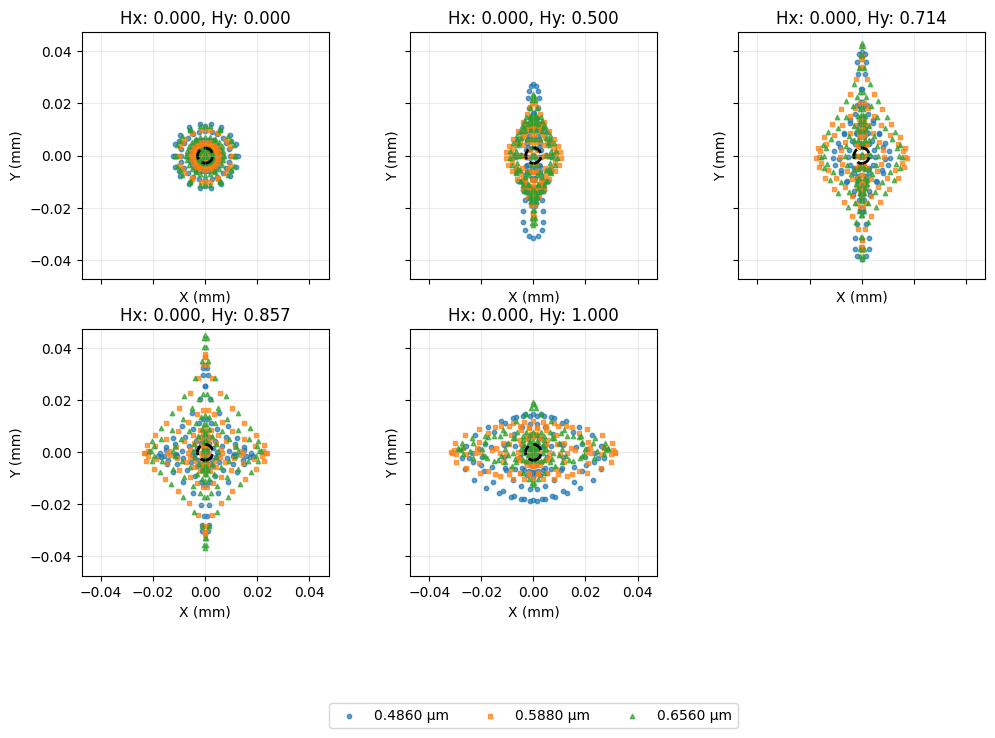

In [114]:
spot = analysis.SpotDiagram(lens)
spot.view(add_airy_disk=True)

(<Figure size 700x700 with 1 Axes>,
 <Axes: title={'center': 'Grid Distortion (Max: 0.68%)'}, xlabel='Image X (mm)', ylabel='Image Y (mm)'>)

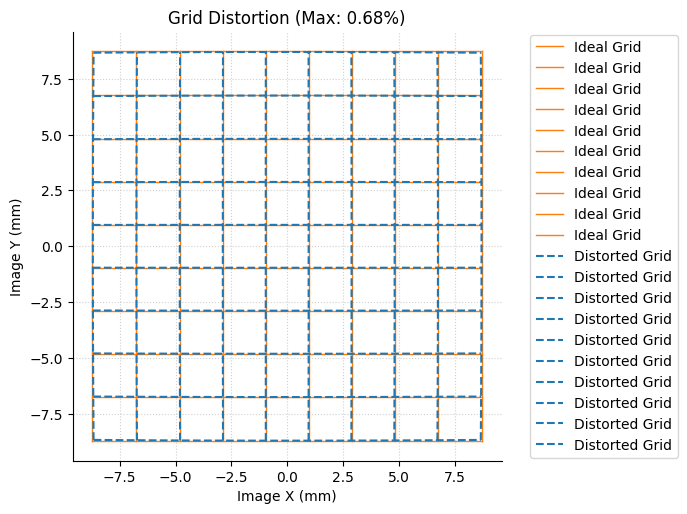

In [115]:
grid_distortion = analysis.GridDistortion(lens)
grid_distortion.view()

In [116]:
fields = lens.fields.get_field_coords()
wavelengths = lens.wavelengths.get_wavelengths()

rms_spot_radius = spot.rms_spot_radius()

weights = [1.0 for _ in fields]

M = 0.0

for i, field in enumerate(fields):
    for j, wavelength in enumerate(wavelengths):
        rms = rms_spot_radius[i][j]

        # Normalize
        normalized = rms / 0.025

        contribution = weights[i] * (normalized ** 2)
        M += contribution

        print(
            f"Field {field[1]:0.3f}, Wavelength {wavelength:.3f} µm, "
            f"RMS: {rms:.4f} mm, Contribution: {contribution:.4f}"
        )

print(f"\nMerit M = {M:.4f}")

Field 0.000, Wavelength 0.486 µm, RMS: 0.0083 mm, Contribution: 0.1108
Field 0.000, Wavelength 0.588 µm, RMS: 0.0061 mm, Contribution: 0.0591
Field 0.000, Wavelength 0.656 µm, RMS: 0.0067 mm, Contribution: 0.0727
Field 0.500, Wavelength 0.486 µm, RMS: 0.0140 mm, Contribution: 0.3144
Field 0.500, Wavelength 0.588 µm, RMS: 0.0116 mm, Contribution: 0.2160
Field 0.500, Wavelength 0.656 µm, RMS: 0.0129 mm, Contribution: 0.2654
Field 0.714, Wavelength 0.486 µm, RMS: 0.0169 mm, Contribution: 0.4550
Field 0.714, Wavelength 0.588 µm, RMS: 0.0169 mm, Contribution: 0.4555
Field 0.714, Wavelength 0.656 µm, RMS: 0.0186 mm, Contribution: 0.5518
Field 0.857, Wavelength 0.486 µm, RMS: 0.0140 mm, Contribution: 0.3131
Field 0.857, Wavelength 0.588 µm, RMS: 0.0166 mm, Contribution: 0.4414
Field 0.857, Wavelength 0.656 µm, RMS: 0.0184 mm, Contribution: 0.5409
Field 1.000, Wavelength 0.486 µm, RMS: 0.0159 mm, Contribution: 0.4021
Field 1.000, Wavelength 0.588 µm, RMS: 0.0165 mm, Contribution: 0.4340
Field 